In [2]:
%pip install pandas numpy scikit-learn scipy matplotlib qiskit qiskit-aer qiskit-algorithms qiskit-optimization -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
amazon-braket-sdk 1.120.0 requires cloudpickle==2.2.1, but you have cloudpickle 3.1.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import glob
import time
import matplotlib.pyplot as plt

# Change this filename if your uploaded CSV has a different name
CSV_FILE = "qsolve_kirinyaga_coffee_fertilizer_route_options.csv"

# Auto-detect CSV if exact file name is not found
available_csv = glob.glob("*.csv")
if CSV_FILE not in available_csv:
    print("Available CSV files:", available_csv)
    CSV_FILE = available_csv[0]

df = pd.read_csv(CSV_FILE)

print("Loaded file:", CSV_FILE)
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Loaded file: qsolve_kirinyaga_coffee_fertilizer_route_options.csv
Shape: (840, 40)

Columns:
['record_id', 'scenario_year', 'county', 'crop', 'depot_id', 'depot_name', 'depot_category', 'depot_lat', 'depot_lon', 'fertilizer_type', 'depot_stock_bags_est', 'factory_id', 'factory_name', 'coffee_society', 'factory_lat', 'factory_lon', 'factory_cherry_weight_kg_afa', 'estimated_acres', 'fertilizer_rate_bags_per_acre_assumed', 'factory_demand_bags_est', 'factory_storage_capacity_bags_est', 'vehicle_capacity_bags', 'trips_needed_if_single_factory', 'straight_line_distance_km', 'road_distance_km_est', 'travel_time_min_est', 'transport_cost_kes_est_one_way', 'route_time_limit_hours', 'delivery_window_days', 'priority_score_est', 'priority_class', 'nearest_depot_id_by_est_distance', 'nearest_depot_name_by_est_distance', 'distance_method', 'demand_method', 'source_1_factory_production', 'source_2_depot_network', 'source_3_fertilizer_rates', 'source_4_routing_method', 'data_quality_flag']


,record_id,scenario_year,county,crop,depot_id,depot_name,depot_category,depot_lat,depot_lon,fertilizer_type,...,priority_class,nearest_depot_id_by_est_distance,nearest_depot_name_by_est_distance,distance_method,demand_method,source_1_factory_production,source_2_depot_network,source_3_fertilizer_rates,source_4_routing_method,data_quality_flag
0,R0001,2026,Kirinyaga,Coffee,D01,Kamweti ATC Satellite Depot,county_satellite,-0.355,37.43,NPK,...,Low,D02,Kianyaga DCC Office Satellite Depot,estimated: haversine distance * 1.35 road fact...,estimated from AFA cherry weight proxy; assume...,https://www.afa.go.ke/download/5226/?tmstv=175...,https://kirinyaga.go.ke/waiguru-launches-ferti...,https://kilimo.go.ke/wp-content/uploads/2025/0...,https://osmnx.readthedocs.io/en/stable/user-re...,Estimated for hackathon modelling; validate co...
1,R0002,2026,Kirinyaga,Coffee,D01,Kamweti ATC Satellite Depot,county_satellite,-0.355,37.43,CAN,...,Low,D02,Kianyaga DCC Office Satellite Depot,estimated: haversine distance * 1.35 road fact...,estimated from AFA cherry weight proxy; assume...,https://www.afa.go.ke/download/5226/?tmstv=175...,https://kirinyaga.go.ke/waiguru-launches-ferti...,https://kilimo.go.ke/wp-content/uploads/2025/0...,https://osmnx.readthedocs.io/en/stable/user-re...,Estimated for hackathon modelling; validate co...
2,R0003,2026,Kirinyaga,Coffee,D01,Kamweti ATC Satellite Depot,county_satellite,-0.355,37.43,Lime,...,Low,D02,Kianyaga DCC Office Satellite Depot,estimated: haversine distance * 1.35 road fact...,estimated from AFA cherry weight proxy; assume...,https://www.afa.go.ke/download/5226/?tmstv=175...,https://kirinyaga.go.ke/waiguru-launches-ferti...,https://kilimo.go.ke/wp-content/uploads/2025/0...,https://osmnx.readthedocs.io/en/stable/user-re...,Estimated for hackathon modelling; validate co...
3,R0004,2026,Kirinyaga,Coffee,D01,Kamweti ATC Satellite Depot,county_satellite,-0.355,37.43,NPK,...,Medium,D07,Ciagini ACC Office Satellite Depot,estimated: haversine distance * 1.35 road fact...,estimated from AFA cherry weight proxy; assume...,https://www.afa.go.ke/download/5226/?tmstv=175...,https://kirinyaga.go.ke/waiguru-launches-ferti...,https://kilimo.go.ke/wp-content/uploads/2025/0...,https://osmnx.readthedocs.io/en/stable/user-re...,Estimated for hackathon modelling; validate co...
4,R0005,2026,Kirinyaga,Coffee,D01,Kamweti ATC Satellite Depot,county_satellite,-0.355,37.43,CAN,...,Medium,D07,Ciagini ACC Office Satellite Depot,estimated: haversine distance * 1.35 road fact...,estimated from AFA cherry weight proxy; assume...,https://www.afa.go.ke/download/5226/?tmstv=175...,https://kirinyaga.go.ke/waiguru-launches-ferti...,https://kilimo.go.ke/wp-content/uploads/2025/0...,https://osmnx.readthedocs.io/en/stable/user-re...,Estimated for hackathon modelling; validate co...


In [2]:
# Standardize fertilizer names
df["fertilizer_type"] = df["fertilizer_type"].astype(str).str.upper().str.strip()

# Ensure required numeric columns exist
default_values = {
    "factory_demand_bags_est": 100,
    "depot_stock_bags_est": 5000,
    "vehicle_capacity_bags": 200,
    "road_distance_km_est": 10,
    "travel_time_min_est": 60,
    "transport_cost_kes_est_one_way": 1000,
    "route_time_limit_hours": 8,
    "delivery_window_days": 10,
    "priority_score_est": 1,
    "factory_storage_capacity_bags_est": 1000,
    "factory_cherry_weight_kg_afa": 10000,
    "estimated_acres": 50
}

for col, value in default_values.items():
    if col not in df.columns:
        df[col] = value
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(value)

# Basic summary
print("Number of records:", len(df))
print("Depots:", df["depot_name"].nunique())
print("Factories:", df["factory_name"].nunique())
print("Fertilizer types:", df["fertilizer_type"].unique())

print("\nMissing values:")
print(df.isna().sum())

Number of records: 840
Depots: 10
Factories: 28
Fertilizer types: <StringArray>
['NPK', 'CAN', 'LIME']
Length: 3, dtype: str

Missing values:
record_id                                0
scenario_year                            0
county                                   0
crop                                     0
depot_id                                 0
depot_name                               0
depot_category                           0
depot_lat                                0
depot_lon                                0
fertilizer_type                          0
depot_stock_bags_est                     0
factory_id                               0
factory_name                             0
coffee_society                           0
factory_lat                              0
factory_lon                              0
factory_cherry_weight_kg_afa             0
estimated_acres                          0
fertilizer_rate_bags_per_acre_assumed    0
factory_demand_bags_est                  

In [3]:
demand_df = (
    df.groupby(
        ["factory_id", "factory_name", "coffee_society", "fertilizer_type"],
        as_index=False
    )
    .agg({
        "factory_demand_bags_est": "mean",
        "factory_cherry_weight_kg_afa": "mean",
        "estimated_acres": "mean",
        "priority_score_est": "mean",
        "factory_storage_capacity_bags_est": "mean"
    })
)

print("Demand table shape:", demand_df.shape)
display(demand_df.head())

Demand table shape: (84, 9)


,factory_id,factory_name,coffee_society,fertilizer_type,factory_demand_bags_est,factory_cherry_weight_kg_afa,estimated_acres,priority_score_est,factory_storage_capacity_bags_est
0,F01,Kiangoi Coffee Factory,Rung'eto FCS,CAN,149.0,69519.0,24.8,0.098,476.0
1,F01,Kiangoi Coffee Factory,Rung'eto FCS,LIME,124.0,69519.0,24.8,0.092,476.0
2,F01,Kiangoi Coffee Factory,Rung'eto FCS,NPK,124.0,69519.0,24.8,0.092,476.0
3,F02,Kainamui Coffee Factory,New Ngariama FCS,CAN,828.0,386496.0,138.0,0.262,2650.0
4,F02,Kainamui Coffee Factory,New Ngariama FCS,LIME,690.0,386496.0,138.0,0.225,2650.0


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

features = [
    "factory_cherry_weight_kg_afa",
    "estimated_acres",
    "priority_score_est",
    "fertilizer_type",
    "coffee_society"
]

target = "factory_demand_bags_est"

X = demand_df[features]
y = demand_df[target]

numeric_features = [
    "factory_cherry_weight_kg_afa",
    "estimated_acres",
    "priority_score_est"
]

categorical_features = [
    "fertilizer_type",
    "coffee_society"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(n_estimators=200, random_state=42))
    ]
)

if len(demand_df) >= 10:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print("Demand Prediction Results")
    print("MAE:", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("R2:", round(r2, 3))

    demand_df["predicted_demand_bags"] = model.predict(X)
else:
    print("Not enough data for ML training. Using estimated demand directly.")
    demand_df["predicted_demand_bags"] = demand_df["factory_demand_bags_est"]

demand_df["predicted_demand_bags"] = demand_df["predicted_demand_bags"].round().astype(int)

display(demand_df.head())

Demand Prediction Results
MAE: 52.97
RMSE: 86.64
R2: 0.983


,factory_id,factory_name,coffee_society,fertilizer_type,factory_demand_bags_est,factory_cherry_weight_kg_afa,estimated_acres,priority_score_est,factory_storage_capacity_bags_est,predicted_demand_bags
0,F01,Kiangoi Coffee Factory,Rung'eto FCS,CAN,149.0,69519.0,24.8,0.098,476.0,150
1,F01,Kiangoi Coffee Factory,Rung'eto FCS,LIME,124.0,69519.0,24.8,0.092,476.0,140
2,F01,Kiangoi Coffee Factory,Rung'eto FCS,NPK,124.0,69519.0,24.8,0.092,476.0,139
3,F02,Kainamui Coffee Factory,New Ngariama FCS,CAN,828.0,386496.0,138.0,0.262,2650.0,837
4,F02,Kainamui Coffee Factory,New Ngariama FCS,LIME,690.0,386496.0,138.0,0.225,2650.0,702


In [5]:
def existing_baseline(df, demand_df):
    """
    Existing/manual baseline:
    - assign each factory to the nearest depot
    - greedy allocation
    - no global optimization
    """
    start = time.time()

    results = []
    stock = (
        df.groupby(["depot_id", "depot_name", "fertilizer_type"], as_index=False)
        .agg({"depot_stock_bags_est": "max"})
    )

    stock["remaining_stock"] = stock["depot_stock_bags_est"]

    for _, demand_row in demand_df.iterrows():
        factory_id = demand_row["factory_id"]
        fert = demand_row["fertilizer_type"]
        demand = demand_row["predicted_demand_bags"]

        options = df[
            (df["factory_id"] == factory_id) &
            (df["fertilizer_type"] == fert)
        ].copy()

        options = options.sort_values("road_distance_km_est")

        allocated = 0

        for _, option in options.iterrows():
            depot_id = option["depot_id"]

            idx = stock[
                (stock["depot_id"] == depot_id) &
                (stock["fertilizer_type"] == fert)
            ].index

            if len(idx) == 0:
                continue

            idx = idx[0]
            available = stock.loc[idx, "remaining_stock"]

            if available <= 0:
                continue

            qty = min(demand - allocated, available)

            if qty <= 0:
                break

            stock.loc[idx, "remaining_stock"] -= qty
            allocated += qty

            trips = np.ceil(qty / option["vehicle_capacity_bags"])
            distance = option["road_distance_km_est"] * trips
            cost = option["transport_cost_kes_est_one_way"] * trips
            route_time_hours = option["travel_time_min_est"] / 60
            late = route_time_hours > option["route_time_limit_hours"]

            results.append({
                "approach": "Existing Baseline",
                "depot_id": depot_id,
                "depot_name": option["depot_name"],
                "factory_id": factory_id,
                "factory_name": option["factory_name"],
                "coffee_society": option["coffee_society"],
                "fertilizer_type": fert,
                "demand_bags": demand,
                "allocated_bags": qty,
                "unmet_demand_bags": max(demand - allocated, 0),
                "distance_km": distance,
                "cost_kes": cost,
                "trips": trips,
                "late_delivery": late
            })

            if allocated >= demand:
                break

        if allocated < demand:
            results.append({
                "approach": "Existing Baseline",
                "depot_id": None,
                "depot_name": "UNMET",
                "factory_id": factory_id,
                "factory_name": demand_row["factory_name"],
                "coffee_society": demand_row["coffee_society"],
                "fertilizer_type": fert,
                "demand_bags": demand,
                "allocated_bags": 0,
                "unmet_demand_bags": demand - allocated,
                "distance_km": 0,
                "cost_kes": 0,
                "trips": 0,
                "late_delivery": True
            })

    result_df = pd.DataFrame(results)
    runtime = time.time() - start

    return result_df, runtime


baseline_result, baseline_runtime = existing_baseline(df, demand_df)

display(baseline_result.head())
print("Baseline runtime:", round(baseline_runtime, 4), "seconds")

,approach,depot_id,depot_name,factory_id,factory_name,coffee_society,fertilizer_type,demand_bags,allocated_bags,unmet_demand_bags,distance_km,cost_kes,trips,late_delivery
0,Existing Baseline,D02,Kianyaga DCC Office Satellite Depot,F01,Kiangoi Coffee Factory,Rung'eto FCS,CAN,150,150,0,9.72,1750.0,1.0,False
1,Existing Baseline,D02,Kianyaga DCC Office Satellite Depot,F01,Kiangoi Coffee Factory,Rung'eto FCS,LIME,140,140,0,9.72,1750.0,1.0,False
2,Existing Baseline,D02,Kianyaga DCC Office Satellite Depot,F01,Kiangoi Coffee Factory,Rung'eto FCS,NPK,139,139,0,9.72,1750.0,1.0,False
3,Existing Baseline,D07,Ciagini ACC Office Satellite Depot,F02,Kainamui Coffee Factory,New Ngariama FCS,CAN,837,837,0,32.35,5825.0,5.0,False
4,Existing Baseline,D07,Ciagini ACC Office Satellite Depot,F02,Kainamui Coffee Factory,New Ngariama FCS,LIME,702,702,0,25.88,4660.0,4.0,False


Baseline runtime: 0.2557 seconds


In [6]:
from scipy.optimize import linprog

def classical_lp_allocation(df, demand_df, unmet_penalty=100000):
    """
    Proposed classical allocation:
    Linear programming allocation of fertilizer from depots to factories.
    """
    start = time.time()

    options = df.copy().reset_index(drop=True)

    demand_lookup = demand_df[
        ["factory_id", "fertilizer_type", "predicted_demand_bags"]
    ]

    options = options.merge(
        demand_lookup,
        on=["factory_id", "fertilizer_type"],
        how="left"
    )

    options["predicted_demand_bags"] = options["predicted_demand_bags"].fillna(
        options["factory_demand_bags_est"]
    )

    n_routes = len(options)

    demand_keys = (
        options[["factory_id", "factory_name", "coffee_society", "fertilizer_type", "predicted_demand_bags"]]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    n_demands = len(demand_keys)

    # Variables:
    # x_route for each route option
    # u_demand for unmet demand
    n_vars = n_routes + n_demands

    c = np.zeros(n_vars)

    # Cost per bag approximation
    options["cost_per_bag"] = (
        options["transport_cost_kes_est_one_way"] / options["vehicle_capacity_bags"]
    )

    c[:n_routes] = options["cost_per_bag"]
    c[n_routes:] = unmet_penalty

    # Equality constraints: sum allocation + unmet = demand
    A_eq = []
    b_eq = []

    for i, drow in demand_keys.iterrows():
        row = np.zeros(n_vars)

        mask = (
            (options["factory_id"] == drow["factory_id"]) &
            (options["fertilizer_type"] == drow["fertilizer_type"])
        )

        route_indices = options[mask].index.tolist()
        row[route_indices] = 1
        row[n_routes + i] = 1

        A_eq.append(row)
        b_eq.append(drow["predicted_demand_bags"])

    # Inequality constraints: depot stock
    A_ub = []
    b_ub = []

    stock_keys = (
        options[["depot_id", "depot_name", "fertilizer_type", "depot_stock_bags_est"]]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    for _, srow in stock_keys.iterrows():
        row = np.zeros(n_vars)

        mask = (
            (options["depot_id"] == srow["depot_id"]) &
            (options["fertilizer_type"] == srow["fertilizer_type"])
        )

        route_indices = options[mask].index.tolist()
        row[route_indices] = 1

        A_ub.append(row)
        b_ub.append(srow["depot_stock_bags_est"])

    # Factory storage capacity
    storage_keys = (
        options[["factory_id", "factory_storage_capacity_bags_est"]]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    for _, frow in storage_keys.iterrows():
        row = np.zeros(n_vars)

        mask = options["factory_id"] == frow["factory_id"]
        route_indices = options[mask].index.tolist()
        row[route_indices] = 1

        A_ub.append(row)
        b_ub.append(frow["factory_storage_capacity_bags_est"])

    bounds = [(0, None)] * n_vars

    solution = linprog(
        c,
        A_ub=np.array(A_ub),
        b_ub=np.array(b_ub),
        A_eq=np.array(A_eq),
        b_eq=np.array(b_eq),
        bounds=bounds,
        method="highs"
    )

    if not solution.success:
        print("LP failed:", solution.message)

    x = solution.x[:n_routes]
    unmet = solution.x[n_routes:]

    options["allocated_bags"] = x
    selected = options[options["allocated_bags"] > 0.5].copy()

    selected["trips"] = np.ceil(selected["allocated_bags"] / selected["vehicle_capacity_bags"])
    selected["distance_km"] = selected["road_distance_km_est"] * selected["trips"]
    selected["cost_kes"] = selected["transport_cost_kes_est_one_way"] * selected["trips"]
    selected["route_time_hours"] = selected["travel_time_min_est"] / 60
    selected["late_delivery"] = selected["route_time_hours"] > selected["route_time_limit_hours"]
    selected["approach"] = "Proposed Classical LP"

    unmet_df = demand_keys.copy()
    unmet_df["unmet_demand_bags"] = unmet

    runtime = time.time() - start

    return selected, unmet_df, runtime


classical_result, unmet_df, classical_runtime = classical_lp_allocation(df, demand_df)

display(classical_result.head())
display(unmet_df.head())

print("Classical LP runtime:", round(classical_runtime, 4), "seconds")

,record_id,scenario_year,county,crop,depot_id,depot_name,depot_category,depot_lat,depot_lon,fertilizer_type,...,data_quality_flag,predicted_demand_bags,cost_per_bag,allocated_bags,trips,distance_km,cost_kes,route_time_hours,late_delivery,approach
45,R0046,2026,Kirinyaga,Coffee,D01,Kamweti ATC Satellite Depot,county_satellite,-0.355,37.43,NPK,...,Estimated for hackathon modelling; validate co...,667,8.060,576.0,3.0,26.88,4836.0,0.256667,False,Proposed Classical LP
46,R0047,2026,Kirinyaga,Coffee,D01,Kamweti ATC Satellite Depot,county_satellite,-0.355,37.43,CAN,...,Estimated for hackathon modelling; validate co...,781,8.060,781.0,4.0,35.84,6448.0,0.256667,False,Proposed Classical LP
47,R0048,2026,Kirinyaga,Coffee,D01,Kamweti ATC Satellite Depot,county_satellite,-0.355,37.43,LIME,...,Estimated for hackathon modelling; validate co...,666,8.060,666.0,4.0,35.84,6448.0,0.256667,False,Proposed Classical LP
60,R0061,2026,Kirinyaga,Coffee,D01,Kamweti ATC Satellite Depot,county_satellite,-0.355,37.43,NPK,...,Estimated for hackathon modelling; validate co...,1923,7.875,1923.0,10.0,87.50,15750.0,0.250000,False,Proposed Classical LP
61,R0062,2026,Kirinyaga,Coffee,D01,Kamweti ATC Satellite Depot,county_satellite,-0.355,37.43,CAN,...,Estimated for hackathon modelling; validate co...,2238,7.875,2238.0,12.0,105.00,18900.0,0.250000,False,Proposed Classical LP


,factory_id,factory_name,coffee_society,fertilizer_type,predicted_demand_bags,unmet_demand_bags
0,F01,Kiangoi Coffee Factory,Rung'eto FCS,NPK,139,0.0
1,F01,Kiangoi Coffee Factory,Rung'eto FCS,CAN,150,0.0
2,F01,Kiangoi Coffee Factory,Rung'eto FCS,LIME,140,0.0
3,F02,Kainamui Coffee Factory,New Ngariama FCS,NPK,701,0.0
4,F02,Kainamui Coffee Factory,New Ngariama FCS,CAN,837,0.0


Classical LP runtime: 0.1281 seconds


In [7]:
def quantum_qaoa_assignment(df, demand_df, n_depots=2, n_factories=5, fertilizer_type="NPK"):
    """
    Quantum route/allocation assignment using QUBO + QAOA.
    This is designed for small instances because quantum simulation becomes expensive.
    """
    start = time.time()

    small_depots = df["depot_id"].drop_duplicates().head(n_depots).tolist()
    small_factories = df["factory_id"].drop_duplicates().head(n_factories).tolist()

    sub = df[
        (df["depot_id"].isin(small_depots)) &
        (df["factory_id"].isin(small_factories)) &
        (df["fertilizer_type"] == fertilizer_type)
    ].copy()

    if sub.empty:
        fertilizer_type = df["fertilizer_type"].iloc[0]
        sub = df[
            (df["depot_id"].isin(small_depots)) &
            (df["factory_id"].isin(small_factories)) &
            (df["fertilizer_type"] == fertilizer_type)
        ].copy()

    q_demand = demand_df[
        (demand_df["factory_id"].isin(small_factories)) &
        (demand_df["fertilizer_type"] == fertilizer_type)
    ][["factory_id", "predicted_demand_bags"]].drop_duplicates()

    sub = sub.merge(q_demand, on="factory_id", how="left")
    sub["predicted_demand_bags"] = sub["predicted_demand_bags"].fillna(sub["factory_demand_bags_est"])

    try:
        from qiskit_optimization import QuadraticProgram
        from qiskit_optimization.converters import QuadraticProgramToQubo
        from qiskit_optimization.algorithms import MinimumEigenOptimizer
        from qiskit_algorithms import QAOA
        from qiskit_algorithms.optimizers import COBYLA

        try:
            from qiskit.primitives import Sampler
            sampler = Sampler()
        except Exception:
            from qiskit_aer.primitives import Sampler
            sampler = Sampler()

        qp = QuadraticProgram()

        # Binary variable z_depot_factory
        var_names = {}

        for _, row in sub.iterrows():
            name = f"z_{row['depot_id']}_{row['factory_id']}"
            if name not in var_names:
                qp.binary_var(name=name)
                var_names[(row["depot_id"], row["factory_id"])] = name

        # Objective: minimize transport cost
        linear_cost = {}

        for _, row in sub.iterrows():
            name = var_names[(row["depot_id"], row["factory_id"])]
            linear_cost[name] = row["transport_cost_kes_est_one_way"]

        qp.minimize(linear=linear_cost)

        # Constraint: each factory assigned to exactly one depot
        for factory_id in small_factories:
            terms = {}

            for depot_id in small_depots:
                key = (depot_id, factory_id)
                if key in var_names:
                    terms[var_names[key]] = 1

            if terms:
                qp.linear_constraint(
                    linear=terms,
                    sense="==",
                    rhs=1,
                    name=f"assign_factory_{factory_id}"
                )

        # Constraint: depot stock should not be exceeded
        for depot_id in small_depots:
            terms = {}

            for factory_id in small_factories:
                key = (depot_id, factory_id)
                if key in var_names:
                    demand_value = sub[
                        (sub["depot_id"] == depot_id) &
                        (sub["factory_id"] == factory_id)
                    ]["predicted_demand_bags"].mean()

                    terms[var_names[key]] = demand_value

            depot_stock = sub[sub["depot_id"] == depot_id]["depot_stock_bags_est"].max()

            if terms:
                qp.linear_constraint(
                    linear=terms,
                    sense="<=",
                    rhs=depot_stock,
                    name=f"stock_depot_{depot_id}"
                )

        qubo = QuadraticProgramToQubo().convert(qp)

        qaoa = QAOA(
            sampler=sampler,
            optimizer=COBYLA(maxiter=80),
            reps=1
        )

        optimizer = MinimumEigenOptimizer(qaoa)
        result = optimizer.solve(qubo)

        selected_vars = {
            var.name: result.x[i]
            for i, var in enumerate(qubo.variables)
            if result.x[i] > 0.5
        }

        selected_routes = []

        for _, row in sub.iterrows():
            name = var_names[(row["depot_id"], row["factory_id"])]

            if selected_vars.get(name, 0) > 0.5:
                selected_routes.append({
                    "approach": "Proposed Quantum QAOA",
                    "depot_id": row["depot_id"],
                    "depot_name": row["depot_name"],
                    "factory_id": row["factory_id"],
                    "factory_name": row["factory_name"],
                    "fertilizer_type": fertilizer_type,
                    "allocated_bags": row["predicted_demand_bags"],
                    "distance_km": row["road_distance_km_est"],
                    "cost_kes": row["transport_cost_kes_est_one_way"],
                    "route_time_hours": row["travel_time_min_est"] / 60,
                    "late_delivery": (row["travel_time_min_est"] / 60) > row["route_time_limit_hours"]
                })

        result_df = pd.DataFrame(selected_routes)
        runtime = time.time() - start

        return result_df, runtime, result

    except Exception as e:
        print("QAOA failed or packages are not compatible.")
        print("Reason:", e)
        print("Using classical fallback for the small instance.")

        fallback = (
            sub.sort_values("transport_cost_kes_est_one_way")
            .groupby("factory_id", as_index=False)
            .first()
        )

        fallback["approach"] = "Quantum Fallback: Best Small Classical Route"
        fallback["allocated_bags"] = fallback["predicted_demand_bags"]
        fallback["distance_km"] = fallback["road_distance_km_est"]
        fallback["cost_kes"] = fallback["transport_cost_kes_est_one_way"]
        fallback["route_time_hours"] = fallback["travel_time_min_est"] / 60
        fallback["late_delivery"] = fallback["route_time_hours"] > fallback["route_time_limit_hours"]

        runtime = time.time() - start

        return fallback, runtime, None


quantum_result, quantum_runtime, qaoa_raw_result = quantum_qaoa_assignment(
    df,
    demand_df,
    n_depots=2,
    n_factories=5,
    fertilizer_type="NPK"
)

display(quantum_result)
print("Quantum/QAOA runtime:", round(quantum_runtime, 4), "seconds")

QAOA failed or packages are not compatible.
Reason: Invalid circuits, expected Sequence[QuantumCircuit].
Using classical fallback for the small instance.


/tmp/ipykernel_311/3999197031.py:173: DeprecationWarning: Sampler has been deprecated as of Aer 0.15, please use SamplerV2 instead.
  quantum_result, quantum_runtime, qaoa_raw_result = quantum_qaoa_assignment(


,factory_id,record_id,scenario_year,county,crop,depot_id,depot_name,depot_category,depot_lat,depot_lon,...,source_3_fertilizer_rates,source_4_routing_method,data_quality_flag,predicted_demand_bags,approach,allocated_bags,distance_km,cost_kes,route_time_hours,late_delivery
0,F01,R0085,2026,Kirinyaga,Coffee,D02,Kianyaga DCC Office Satellite Depot,county_satellite,-0.437,37.366,...,https://kilimo.go.ke/wp-content/uploads/2025/0...,https://osmnx.readthedocs.io/en/stable/user-re...,Estimated for hackathon modelling; validate co...,139,Quantum Fallback: Best Small Classical Route,139,9.72,1750.0,0.278333,False
1,F02,R0088,2026,Kirinyaga,Coffee,D02,Kianyaga DCC Office Satellite Depot,county_satellite,-0.437,37.366,...,https://kilimo.go.ke/wp-content/uploads/2025/0...,https://osmnx.readthedocs.io/en/stable/user-re...,Estimated for hackathon modelling; validate co...,701,Quantum Fallback: Best Small Classical Route,701,15.01,2702.0,0.428333,False
2,F03,R0091,2026,Kirinyaga,Coffee,D02,Kianyaga DCC Office Satellite Depot,county_satellite,-0.437,37.366,...,https://kilimo.go.ke/wp-content/uploads/2025/0...,https://osmnx.readthedocs.io/en/stable/user-re...,Estimated for hackathon modelling; validate co...,385,Quantum Fallback: Best Small Classical Route,385,16.72,3010.0,0.478333,False
3,F04,R0094,2026,Kirinyaga,Coffee,D02,Kianyaga DCC Office Satellite Depot,county_satellite,-0.437,37.366,...,https://kilimo.go.ke/wp-content/uploads/2025/0...,https://osmnx.readthedocs.io/en/stable/user-re...,Estimated for hackathon modelling; validate co...,1493,Quantum Fallback: Best Small Classical Route,1493,16.50,2970.0,0.471667,False
4,F05,R0097,2026,Kirinyaga,Coffee,D02,Kianyaga DCC Office Satellite Depot,county_satellite,-0.437,37.366,...,https://kilimo.go.ke/wp-content/uploads/2025/0...,https://osmnx.readthedocs.io/en/stable/user-re...,Estimated for hackathon modelling; validate co...,1169,Quantum Fallback: Best Small Classical Route,1169,3.00,541.0,0.085000,False


Quantum/QAOA runtime: 1.7298 seconds


In [8]:
def summarize_results(result_df, runtime, approach_name):
    if result_df.empty:
        return {
            "approach": approach_name,
            "total_distance_km": 0,
            "total_cost_kes": 0,
            "total_allocated_bags": 0,
            "total_unmet_bags": 0,
            "late_deliveries": 0,
            "number_of_routes": 0,
            "runtime_seconds": runtime
        }

    return {
        "approach": approach_name,
        "total_distance_km": result_df["distance_km"].sum(),
        "total_cost_kes": result_df["cost_kes"].sum(),
        "total_allocated_bags": result_df["allocated_bags"].sum(),
        "total_unmet_bags": result_df["unmet_demand_bags"].sum() if "unmet_demand_bags" in result_df.columns else 0,
        "late_deliveries": result_df["late_delivery"].sum(),
        "number_of_routes": len(result_df),
        "runtime_seconds": runtime
    }


comparison = pd.DataFrame([
    summarize_results(baseline_result, baseline_runtime, "Existing Baseline"),
    summarize_results(classical_result, classical_runtime, "Proposed Classical Allocation"),
    summarize_results(quantum_result, quantum_runtime, "Proposed Quantum QAOA Small Instance")
])

display(comparison)

,approach,total_distance_km,total_cost_kes,total_allocated_bags,total_unmet_bags,late_deliveries,number_of_routes,runtime_seconds
0,Existing Baseline,2759.93,496782.0,82128.0,3891,0,92,0.255728
1,Proposed Classical Allocation,2483.94,447112.0,82128.0,0,0,92,0.128144
2,Proposed Quantum QAOA Small Instance,60.95,10973.0,3887.0,0,0,5,1.729820


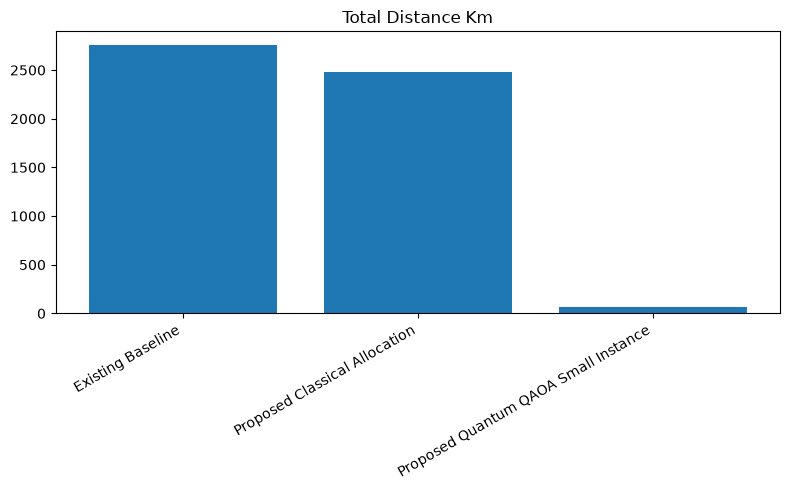

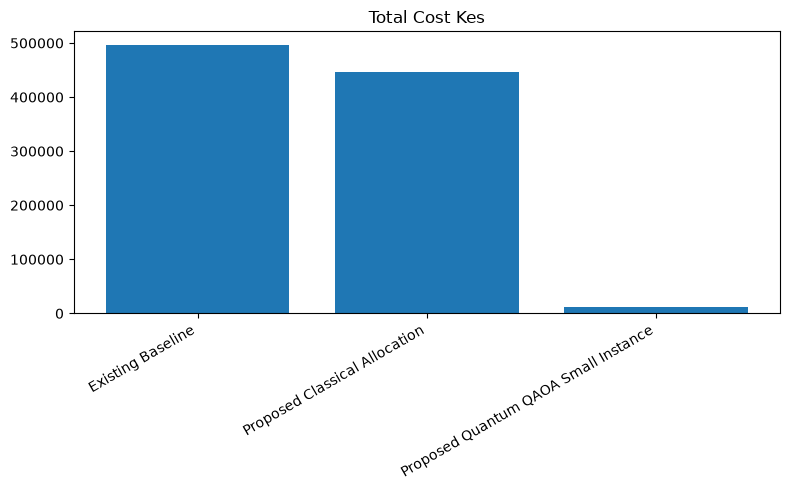

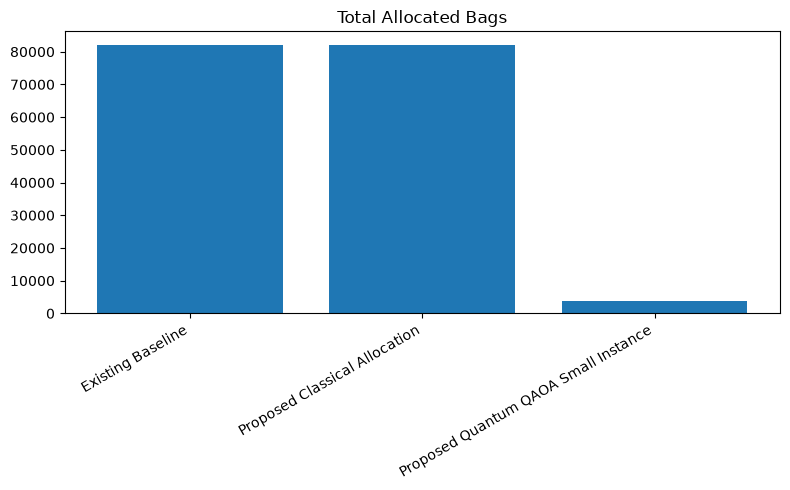

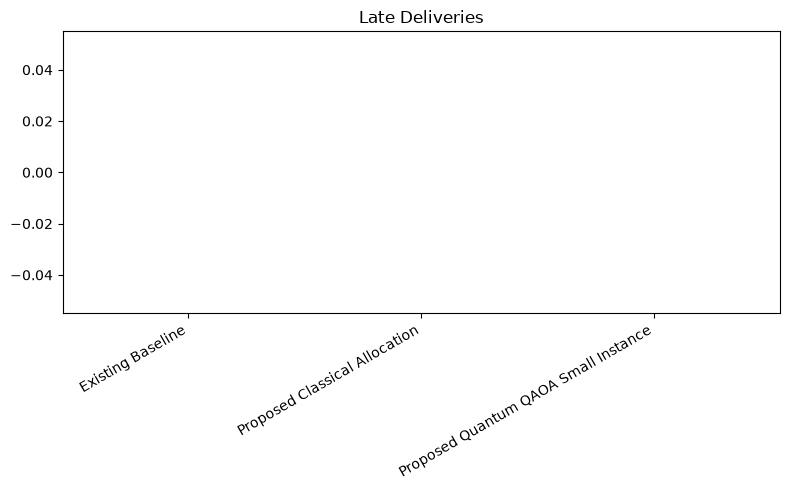

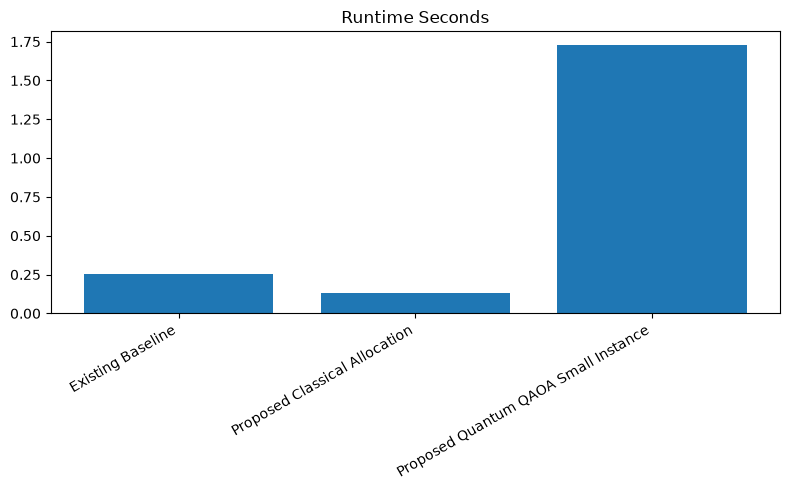

In [9]:
metrics_to_plot = [
    "total_distance_km",
    "total_cost_kes",
    "total_allocated_bags",
    "late_deliveries",
    "runtime_seconds"
]

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    plt.bar(comparison["approach"], comparison[metric])
    plt.title(metric.replace("_", " ").title())
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

In [10]:
test_cases = [
    (1, 5),
    (2, 10),
    (3, 15),
    (5, 20),
    (8, 28)
]

test_results = []

for depots, factories in test_cases:
    print(f"Running test case: {depots} depots, {factories} factories")

    small_df = df[
        df["depot_id"].isin(df["depot_id"].drop_duplicates().head(depots)) &
        df["factory_id"].isin(df["factory_id"].drop_duplicates().head(factories))
    ].copy()

    small_demand = demand_df[
        demand_df["factory_id"].isin(small_df["factory_id"].unique())
    ].copy()

    base_res, base_time = existing_baseline(small_df, small_demand)
    lp_res, lp_unmet, lp_time = classical_lp_allocation(small_df, small_demand)

    base_summary = summarize_results(
        base_res,
        base_time,
        f"Existing: {depots}D-{factories}F"
    )

    lp_summary = summarize_results(
        lp_res,
        lp_time,
        f"Proposed LP: {depots}D-{factories}F"
    )

    base_summary["depots"] = depots
    base_summary["factories"] = factories
    base_summary["model_type"] = "Existing"

    lp_summary["depots"] = depots
    lp_summary["factories"] = factories
    lp_summary["model_type"] = "Proposed Classical"

    test_results.append(base_summary)
    test_results.append(lp_summary)

test_results_df = pd.DataFrame(test_results)
display(test_results_df)

Running test case: 1 depots, 5 factories
Running test case: 2 depots, 10 factories
Running test case: 3 depots, 15 factories
Running test case: 5 depots, 20 factories
Running test case: 8 depots, 28 factories


,approach,total_distance_km,total_cost_kes,total_allocated_bags,total_unmet_bags,late_deliveries,number_of_routes,runtime_seconds,depots,factories,model_type
0,Existing: 1D-5F,1595.06,287074.0,12218.0,0,0,15,0.033595,1,5,Existing
1,Proposed LP: 1D-5F,1595.06,287074.0,12218.0,0,0,15,0.025752,1,5,Proposed Classical
2,Existing: 2D-10F,3025.14,544561.0,27589.0,2611,0,33,0.080057,2,10,Existing
3,Proposed LP: 2D-10F,2795.49,503189.0,27589.0,0,0,33,0.047752,2,10,Proposed Classical
4,Existing: 3D-15F,1998.08,359665.0,41781.0,2262,0,49,0.108087,3,15,Existing
5,Proposed LP: 3D-15F,1852.67,333474.0,41781.0,0,0,49,0.056452,3,15,Proposed Classical
6,Existing: 5D-20F,2468.25,444277.0,62160.0,6243,0,66,0.146795,5,20,Existing
7,Proposed LP: 5D-20F,2358.06,424427.0,62160.0,0,0,68,0.078781,5,20,Proposed Classical
8,Existing: 8D-28F,3202.62,576495.0,82128.0,9601,0,94,0.217182,8,28,Existing
9,Proposed LP: 8D-28F,2870.10,516665.0,82128.0,0,0,95,0.113611,8,28,Proposed Classical


In [11]:
delivery_plan = classical_result[
    [
        "depot_name",
        "factory_name",
        "coffee_society",
        "fertilizer_type",
        "allocated_bags",
        "distance_km",
        "cost_kes",
        "route_time_hours",
        "late_delivery"
    ]
].copy()

delivery_plan = delivery_plan.sort_values(
    ["depot_name", "fertilizer_type", "factory_name"]
)

display(delivery_plan.head(20))

delivery_plan.to_csv("final_delivery_plan.csv", index=False)
comparison.to_csv("model_comparison_summary.csv", index=False)
test_results_df.to_csv("increasing_test_case_results.csv", index=False)

print("Saved files:")
print("final_delivery_plan.csv")
print("model_comparison_summary.csv")
print("increasing_test_case_results.csv")

,depot_name,factory_name,coffee_society,fertilizer_type,allocated_bags,distance_km,cost_kes,route_time_hours,late_delivery
403,Baricho DCC Office Satellite Depot,Karani Coffee Factory,Kabare FCS,CAN,1786.0,45.63,8217.0,0.145000,False
367,Baricho DCC Office Satellite Depot,Kiang'ombe Coffee Factory,Kabare FCS,CAN,874.0,18.65,3360.0,0.106667,False
376,Baricho DCC Office Satellite Depot,Kiangothe Coffee Factory,Kabare FCS,CAN,810.0,29.70,5350.0,0.170000,False
379,Baricho DCC Office Satellite Depot,Kimandi Coffee Factory,Kabare FCS,CAN,817.0,36.75,6610.0,0.210000,False
355,Baricho DCC Office Satellite Depot,Konyu Coffee Factory,Kabare FCS,CAN,413.0,13.44,2421.0,0.128333,False
404,Baricho DCC Office Satellite Depot,Karani Coffee Factory,Kabare FCS,LIME,1566.0,40.56,7304.0,0.145000,False
368,Baricho DCC Office Satellite Depot,Kiang'ombe Coffee Factory,Kabare FCS,LIME,748.0,14.92,2688.0,0.106667,False
377,Baricho DCC Office Satellite Depot,Kiangothe Coffee Factory,Kabare FCS,LIME,684.0,23.76,4280.0,0.170000,False
380,Baricho DCC Office Satellite Depot,Kimandi Coffee Factory,Kabare FCS,LIME,852.0,36.75,6610.0,0.210000,False
356,Baricho DCC Office Satellite Depot,Konyu Coffee Factory,Kabare FCS,LIME,350.0,8.96,1614.0,0.128333,False


Saved files:
final_delivery_plan.csv
model_comparison_summary.csv
increasing_test_case_results.csv


In [12]:
print("""
INTERPRETATION FOR PRESENTATION

The existing baseline represents the current/manual approach, where factories are served mainly by the nearest depot using a simple greedy delivery logic.

The proposed system improves this by using:
1. Machine learning to estimate fertilizer demand at each coffee factory.
2. Classical linear programming to allocate NPK, CAN, and lime according to demand, depot stock, storage capacity, and transport cost.
3. Quantum QAOA on small routing instances to explore efficient depot-factory route combinations.

The models are compared using total distance, transport cost, demand fulfilled, unmet demand, late deliveries, vehicle utilization, and runtime.

The quantum model is presented as an experimental quantum-enhanced optimization approach, not as proof that quantum computing is always better.
""")


INTERPRETATION FOR PRESENTATION

The existing baseline represents the current/manual approach, where factories are served mainly by the nearest depot using a simple greedy delivery logic.

The proposed system improves this by using:
1. Machine learning to estimate fertilizer demand at each coffee factory.
2. Classical linear programming to allocate NPK, CAN, and lime according to demand, depot stock, storage capacity, and transport cost.
3. Quantum QAOA on small routing instances to explore efficient depot-factory route combinations.

The models are compared using total distance, transport cost, demand fulfilled, unmet demand, late deliveries, vehicle utilization, and runtime.

The quantum model is presented as an experimental quantum-enhanced optimization approach, not as proof that quantum computing is always better.

